In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import os
import joblib
import json

from sklearn.model_selection import ParameterSampler, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme()

# Prepare dataset

In [2]:
INPUT_COLS = ["S0", "taus", "rs", "sigma"]
OUTPUT_COL = ["price"]
DATA_DIR = "data"
CHECKOPOINT_DIR = "checkpoints"

In [3]:
df = pd.read_csv(f"{DATA_DIR}/synthetic_data-bs.csv")
df = df.dropna()

mask = (
    (df["price"] >= 0) &
    (df["price"] <= df["S0"])
)
df = df[mask]

low, high = df["price"].quantile([0.001, 0.999])
df = df[(df["price"] >= low) & (df["price"] <= high)]

mu = df["price"].mean()
sigma = df["price"].std()

df = df[np.abs((df["price"] - mu) / sigma) < 5]

In [4]:
df_small = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
X = df_small[INPUT_COLS].values.astype('float32')
y = df_small[OUTPUT_COL].values.astype('float32')

# Prices Neural Network
## Hyperparameters optimization

In [5]:
# Hyperparameter space
param_space = {
    "activation": ["relu", "elu"],
    "hidden_neurons": st.randint(200, 600),
    "optimizer": ["SGD", "RMSprop", "Adam"],
    "lr": st.loguniform(1e-4, 1e-2),
    "use_bn": ["True", "False"],
    "batch_size": st.randint(128, 2048),
}

# Map strings to PyTorch activation functions
activation_map = {
    "relu": nn.ReLU,
    "elu": nn.ELU
}

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_neurons=400, n_hidden=4, activation=nn.ReLU, use_bn=False):
        super().__init__()
        layers = []
        in_dim = input_dim
        
        for _ in range(n_hidden):
            layers.append(nn.Linear(in_dim, hidden_neurons))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_neurons))
            layers.append(activation())
            in_dim = hidden_neurons
        
        layers.append(nn.Linear(in_dim, out_features=1))
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def forward(self, x):
        return self.net(x)

In [7]:
def eval_config(config):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    val_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        y_tr = y_tr.reshape(-1, 1)
        y_val = y_val.reshape(-1, 1)

        xsc = StandardScaler().fit(X_tr)
        ysc = StandardScaler().fit(y_tr)

        X_tr_s = xsc.transform(X_tr)
        X_val_s = xsc.transform(X_val)
        y_tr_s = ysc.transform(y_tr)
        y_val_s = ysc.transform(y_val)
        
        bs = config["batch_size"]
        
        train_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_s)),
            batch_size=bs, shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_val_s), torch.from_numpy(y_val_s)),
            batch_size=bs, shuffle=False
        )
        
        model = MLP(
            input_dim=X.shape[1],
            hidden_neurons=config["hidden_neurons"],
            activation=activation_map[config["activation"]],
            use_bn=config["use_bn"]
        )
        
        lr = config["lr"]
        if config["optimizer"] == "SGD":
            opt = optim.SGD(model.parameters(), lr=lr)
        elif config["optimizer"] == "RMSprop":
            opt = optim.RMSprop(model.parameters(), lr=lr)
        else:
            opt = optim.Adam(model.parameters(), lr=lr)
        
        criterion = nn.MSELoss()
        
        for epoch in range(50):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.float(), yb.float()
                pred = model(xb)
                loss = criterion(pred, yb)
                
                opt.zero_grad()
                loss.backward()
                # Clip gradients to prevent explosion
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
        
        model.eval()
        total_sse_original_scale = 0.0
        n_samples = 0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.float()
                
                out_scaled = model(xb).cpu().numpy()
                out_real = ysc.inverse_transform(out_scaled)
                
                y_real = ysc.inverse_transform(yb.numpy())

                batch_sse = np.sum((out_real - y_real)**2)
                total_sse_original_scale += batch_sse
                n_samples += xb.shape[0]
        
        val_scores.append(total_sse_original_scale / n_samples)

    return float(np.mean(val_scores))
                

def perform_random_search(param_space, n_iter):
    sampler = list(ParameterSampler(param_space, n_iter=n_iter, random_state=42))
    results = []
    
    
    for i, sample in enumerate(sampler, start=1):
        try:
            score = eval_config(sample)
        except Exception as e:
            print(f"error: {e}")
            score = float("inf")
        
        results.append({"config": sample, "val_mse": score})
        print(f"{i}/{n_iter}, MSE: {score:.6e}")
    return results

In [8]:
results = perform_random_search(param_space, n_iter=50)

1/50, MSE: 5.517845e-02
2/50, MSE: 1.006620e-02
3/50, MSE: 9.039504e-04
4/50, MSE: 7.122722e-02
5/50, MSE: 8.543534e-02
6/50, MSE: 3.302162e-04
7/50, MSE: 2.353443e-03
8/50, MSE: 2.313330e-04
9/50, MSE: 3.424564e-03
10/50, MSE: 1.052382e-03
11/50, MSE: 6.806957e-04
12/50, MSE: 4.914932e-02
13/50, MSE: 1.811527e-04
14/50, MSE: 2.226768e-03
15/50, MSE: 1.952427e-03
16/50, MSE: 1.403056e-02
17/50, MSE: 2.613653e-04
18/50, MSE: 2.122855e-04
19/50, MSE: 1.503193e-04
20/50, MSE: 1.362218e-04
21/50, MSE: 1.826358e-04
22/50, MSE: 1.240699e-04
23/50, MSE: 9.768055e-04
24/50, MSE: 5.509931e-04
25/50, MSE: 4.849685e-04
26/50, MSE: 5.432939e-04
27/50, MSE: 1.226184e-03
28/50, MSE: 7.904432e-05
29/50, MSE: 4.612158e-02
30/50, MSE: 9.760286e-04
31/50, MSE: 1.115975e-03
32/50, MSE: 2.210393e-03
33/50, MSE: 1.174135e-02
34/50, MSE: 4.187196e-03
35/50, MSE: 2.972424e-04
36/50, MSE: 1.664308e-03
37/50, MSE: 1.718010e-04
38/50, MSE: 4.623910e-02
39/50, MSE: 3.205625e-04
40/50, MSE: 1.097730e-03
41/50, MS

In [9]:
sorted_results = sorted(results, key=lambda d: d["val_mse"])
sorted_results[0]

{'config': {'activation': 'relu',
  'batch_size': 223,
  'hidden_neurons': 587,
  'lr': np.float64(0.006533305220227739),
  'optimizer': 'Adam',
  'use_bn': 'True'},
 'val_mse': 7.904432277427986e-05}

# Calculating $R^2$ and errors

In [10]:
def train_model_for_config(config, X_train, y_train, X_val, y_val, X_test, y_test, epochs=3000):
    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    xsc = StandardScaler().fit(X_train)
    ysc = StandardScaler().fit(y_train)

    X_tr_s = xsc.transform(X_train)
    X_val_s = xsc.transform(X_val)
    X_test_s = xsc.transform(X_test)
    y_tr_s = ysc.transform(y_train)
    y_val_s = ysc.transform(y_val)
    
    bs = config["batch_size"]
    
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_s)),
        batch_size=bs, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val_s), torch.from_numpy(y_val_s)),
        batch_size=bs, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_test_s), torch.from_numpy(y_test)),
        batch_size=bs, shuffle=False
    )
    
    model = MLP(
        input_dim=X_train.shape[1],
        hidden_neurons=config["hidden_neurons"],
        activation=activation_map[config["activation"]],
        use_bn=config["use_bn"]
    )
    
    lr = config["lr"]
    if config["optimizer"] == "SGD":
        opt = optim.SGD(model.parameters(), lr=lr)
    elif config["optimizer"] == "RMSprop":
        opt = optim.RMSprop(model.parameters(), lr=lr)
    else:
        opt = optim.Adam(model.parameters(), lr=lr)
    
    criterion = nn.MSELoss()
    best_val = np.inf

    for epoch in range(epochs):
        # ---- training ----
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.float(), yb.float()
            pred = model(xb)
            loss = criterion(pred, yb)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- validation ----
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.float(), yb.float()
                pred = model(xb)
                val_loss += criterion(pred, yb).item()

        val_loss /= len(val_loader)

        # ---- early stopping logic ----
        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())

        # ---- logging ----
        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Train MSE: {train_loss:.3e} | "
                f"Val MSE: {val_loss:.3e} | "
                f"Best Val: {best_val:.3e} | "
            )

    # restore best model
    model.load_state_dict(best_state)
    return model, xsc, ysc

In [11]:
X = df[INPUT_COLS].values.astype('float32')
y = df[OUTPUT_COL].values.astype('float32')

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, train_size=0.8, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=42
)

In [12]:
sorted_results[0]["config"]

{'activation': 'relu',
 'batch_size': 223,
 'hidden_neurons': 587,
 'lr': np.float64(0.006533305220227739),
 'optimizer': 'Adam',
 'use_bn': 'True'}

In [13]:
fname = f"{CHECKOPOINT_DIR}/nn_price.pth"

if os.path.isfile(fname):
    ckpt = torch.load(fname)
    with open(f"{CHECKOPOINT_DIR}/config_nn.json") as f:
        config = json.load(f)

    model = MLP(
        input_dim=X_train.shape[1],
        hidden_neurons=config["hidden_neurons"],
        activation=activation_map[config["activation"]],
        use_bn=config["use_bn"]
    )

    model.load_state_dict(torch.load(fname))
    model.eval()

    xsc = joblib.load(f"{CHECKOPOINT_DIR}/xsc_nn.pkl")
    ysc = joblib.load(f"{CHECKOPOINT_DIR}/ysc_nn.pkl")
else:
    best_config = sorted_results[0]["config"]
    model, xsc, ysc = train_model_for_config(
        config=best_config,
        X_train=X_train, 
        y_train=y_train,
        X_val=X_val, 
        y_val=y_val,
        X_test=X_test, 
        y_test=y_test,
        epochs=3000
    )
    torch.save(model.state_dict(), fname)
    joblib.dump(xsc, f"{CHECKOPOINT_DIR}/xsc_nn.pkl")
    joblib.dump(ysc, f"{CHECKOPOINT_DIR}/ysc_nn.pkl")

# PLOTS!

In [14]:
def predict(model, X, xsc, ysc, batch_size=2048):
    model.eval()
    Xs = xsc.transform(X)
    preds = []

    with torch.no_grad():
        for i in range(0, len(Xs), batch_size):
            xb = torch.from_numpy(Xs[i:i+batch_size]).float()
            yb = model(xb).cpu().numpy()
            preds.append(yb)

    preds = np.vstack(preds)
    return ysc.inverse_transform(preds).ravel()

y_true = y_test.ravel()
y_pred = predict(model, X_test, xsc, ysc)
resid = y_pred - y_true
r2 = r2_score(y_true, y_pred)

## Model Performance

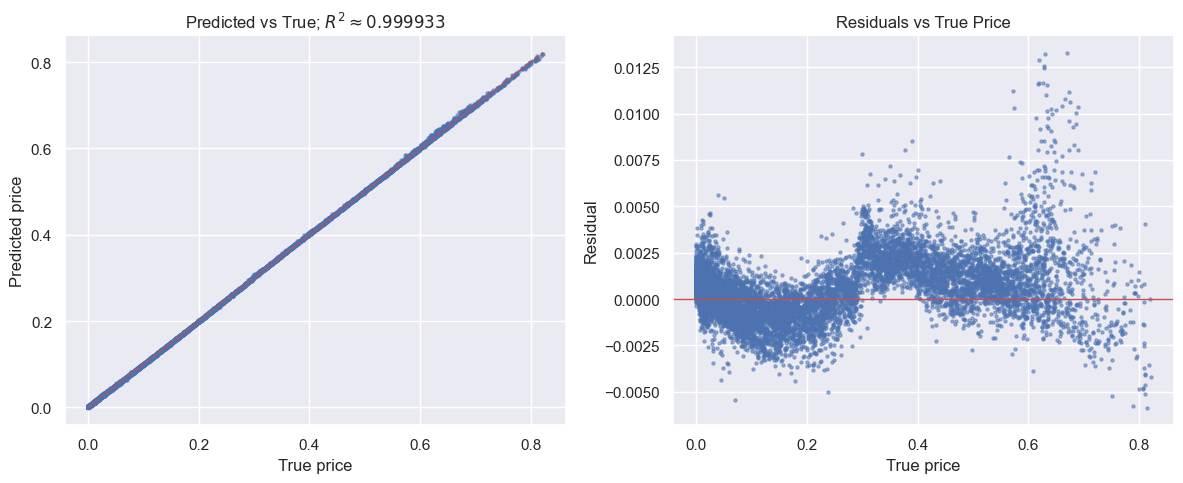

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs True
ax[0].scatter(y_true, y_pred, s=5, alpha=0.5)
lims = [0, max(y_true.max(), y_pred.max())]
ax[0].plot(lims, lims, 'r--', lw=1)
ax[0].set_xlabel("True price")
ax[0].set_ylabel("Predicted price")
ax[0].set_title(rf"Predicted vs True; $R^2 \approx {r2:.6f}$ ")

# Residuals vs True Price
ax[1].scatter(y_true, resid, s=5, alpha=0.5)
ax[1].axhline(0, color="r", lw=1)
ax[1].set_xlabel("True price")
ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals vs True Price")

fig.tight_layout()
plt.show()

## Error Distribution Diagnostics

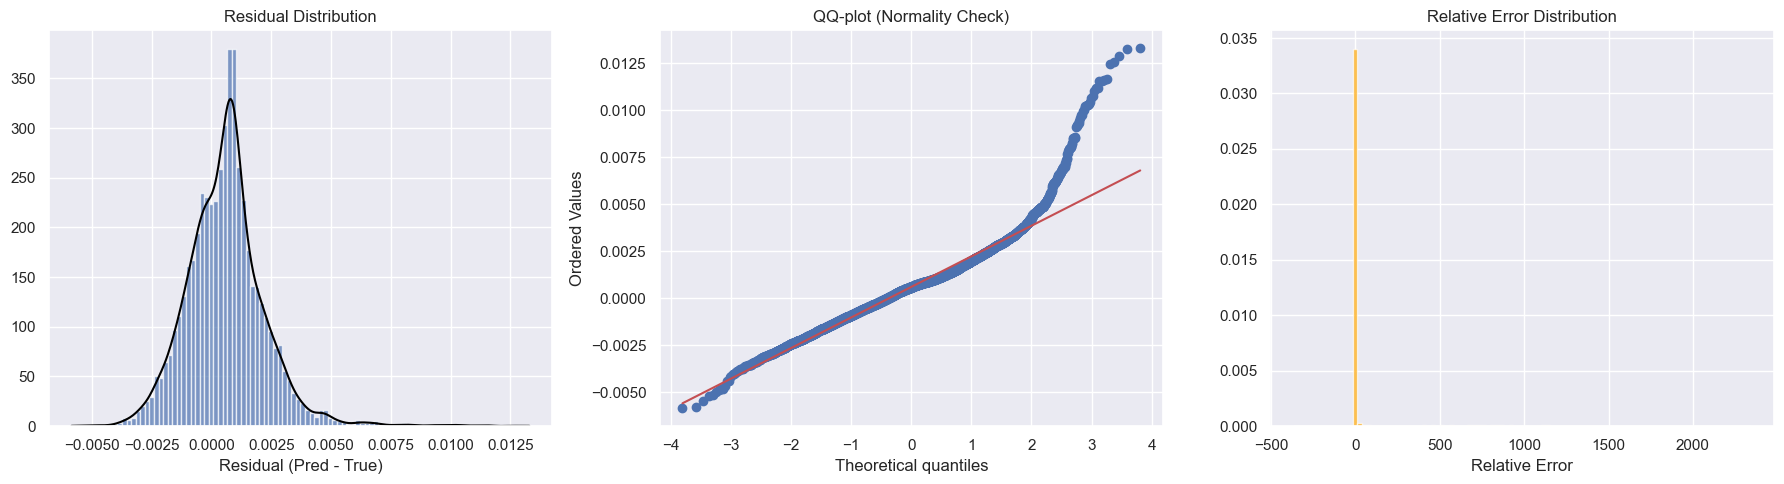

In [16]:
eps = 1e-6
rel_err = resid / (y_true + eps)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Residual Histogram + KDE
ax[0].hist(resid, bins="sqrt", density=True, alpha=0.7)
x_range = np.linspace(resid.min(), resid.max(), 500)
ax[0].plot(x_range, st.gaussian_kde(resid)(x_range), color='black')
ax[0].set_xlabel("Residual (Pred - True)")
ax[0].set_title("Residual Distribution")

# QQ-plot
st.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot (Normality Check)")

# Relative Error Distribution
ax[2].hist(rel_err, bins="sqrt", density=True, alpha=0.7, color='orange')
ax[2].set_xlabel("Relative Error")
ax[2].set_title("Relative Error Distribution")

fig.tight_layout()
plt.show()

In [17]:
print("Relative error percentiles:")
for q in [50, 90, 95, 99]:
    print(f"{q}%: {np.percentile(np.abs(rel_err), q):.4e}")

Relative error percentiles:
50%: 6.5721e-03
90%: 1.7774e+00
95%: 4.3237e+02
99%: 1.1206e+03
